# Imports

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
from skimage import io
import pandas as pd
import random
from collections import defaultdict

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D

In [3]:
random.seed(42)

# Dataset

In [4]:
path_capturasVR = "../capturas/capturas_256x256/capturasVR"

In [5]:
database = os.listdir(path_capturasVR)
data_img_labels = database[0]
imgs = database[1:]
print(database)
print(imgs)

['database.csv', 'Session_001', 'Session_002', 'Session_003', 'Session_004', 'Session_005', 'Session_006', 'Session_007']
['Session_001', 'Session_002', 'Session_003', 'Session_004', 'Session_005', 'Session_006', 'Session_007']


In [11]:
csv_path = os.path.join(path_capturasVR, data_img_labels)

df = pd.read_csv(csv_path)

# Añadir ruta completa a cada imagen
df["full_path"] = df["filename"].apply(lambda x: os.path.join(path_capturasVR, x))

# Separar sesión
df["session"] = df["filename"].str.split("/").str[0]

print(df[["session", "filename", "label"]].head())


       session                      filename         label
0  Session_001  Session_001/capture_0000.png  colocarPilar
1  Session_001  Session_001/capture_0001.png  colocarPilar
2  Session_001  Session_001/capture_0002.png  colocarPilar
3  Session_001  Session_001/capture_0003.png  colocarPilar
4  Session_001  Session_001/capture_0004.png  colocarPilar


In [12]:
for p in imgs:    
    img_path = os.path.join(path_capturasVR, p)
    print(img_path)

../capturas/capturas_256x256/capturasVR\Session_001
../capturas/capturas_256x256/capturasVR\Session_002
../capturas/capturas_256x256/capturasVR\Session_003
../capturas/capturas_256x256/capturasVR\Session_004


# Data augmentation

# Time Series
Given a window of n images, predict n+1

In [13]:
seq_by_session = {}

for entry in os.listdir(path_capturasVR):
    entry_path = os.path.join(path_capturasVR, entry)
    # comprobar que es un directorio y que empieza por "Session_"
    if os.path.isdir(entry_path) and entry.startswith("Session_"):
        # filtrar imágenes .png y ordenar
        image_files = [f for f in os.listdir(entry_path) if f.endswith(".png")]
        image_paths = [os.path.join(entry_path, f) for f in sorted(image_files)]
        seq_by_session[entry] = image_paths

In [14]:
print(seq_by_session)

{'Session_001': ['../capturas/capturas_256x256/capturasVR\\Session_001\\capture_0000.png', '../capturas/capturas_256x256/capturasVR\\Session_001\\capture_0001.png', '../capturas/capturas_256x256/capturasVR\\Session_001\\capture_0002.png', '../capturas/capturas_256x256/capturasVR\\Session_001\\capture_0003.png', '../capturas/capturas_256x256/capturasVR\\Session_001\\capture_0004.png', '../capturas/capturas_256x256/capturasVR\\Session_001\\capture_0005.png', '../capturas/capturas_256x256/capturasVR\\Session_001\\capture_0006.png', '../capturas/capturas_256x256/capturasVR\\Session_001\\capture_0007.png', '../capturas/capturas_256x256/capturasVR\\Session_001\\capture_0008.png', '../capturas/capturas_256x256/capturasVR\\Session_001\\capture_0009.png', '../capturas/capturas_256x256/capturasVR\\Session_001\\capture_0010.png', '../capturas/capturas_256x256/capturasVR\\Session_001\\capture_0011.png', '../capturas/capturas_256x256/capturasVR\\Session_001\\capture_0012.png', '../capturas/capturas

In [15]:
# Crear X_train e Y_train y X_test e Y_test
sessions = list(seq_by_session.keys())

train_ratio = 0.8
n_train = int(len(sessions) * train_ratio)

random.shuffle(sessions)
sessions_train = sessions[:n_train]
sessions_test = sessions[n_train:]

In [16]:
print(sessions_train)
print(sessions_test)

['Session_003', 'Session_002', 'Session_004']
['Session_001']


In [17]:
seq_train = {k: seq_by_session[k] for k in sessions_train}
seq_test  = {k: seq_by_session[k] for k in sessions_test}

In [18]:
def load_and_preprocess(img_path):
    img = image.load_img(img_path, target_size=(256, 256))  
    img = image.img_to_array(img)  # (256, 256, 3)
    img = img / 255.0  
    return img

In [19]:
def sequence_imgs(session_path, n_timesteps): 
    X, Y = [], []

    if len(session_path) <= n_timesteps:
        return X, Y

    for i in range(len(session_path) - n_timesteps):
        input_paths = session_path[i:i+n_timesteps]         # 5 imágenes
        target_path = session_path[i+n_timesteps]           # 1 imagen siguiente

        x_batch = [load_and_preprocess(p) for p in input_paths]
        y_img   = load_and_preprocess(target_path)

        X.append(np.array(x_batch))
        Y.append(y_img)

    return np.array(X), np.array(Y)

In [20]:
window_size = 5

def sequence_imgs_all_sessions(seq_dict, n_timesteps):
    X_total, Y_total = [], []
    for session, paths in seq_dict.items():
        X_sess, Y_sess = sequence_imgs(paths, n_timesteps)
        X_total.extend(X_sess)
        Y_total.extend(Y_sess)
        
    return np.array(X_total), np.array(Y_total)

In [21]:
X_train, Y_train = sequence_imgs_all_sessions(seq_train, window_size)
X_test,  Y_test  = sequence_imgs_all_sessions(seq_test,  window_size)

In [26]:
model = Sequential([
   
    ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=True,
        input_shape=(5, 256, 256, 3)
    ),
    BatchNormalization(),
    ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=False
    ),
    Conv2D(
        filters=3,
        kernel_size=(3, 3),
        activation="sigmoid",
        padding="same"
    )
])


C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer="adam", loss="mse", metrics=["mae", "accuracy"])
model.summary()


# Training
history = model.fit(
    X_train, Y_train,
    epochs=10,
    batch_size=4,
    verbose=1, 
    validation_split=0.2
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d_2 (ConvLSTM2D)      │ (None, 5, 256, 256,    │        40,448 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 256, 256,    │           128 │
│ (BatchNormalization)            │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_3 (ConvLSTM2D)      │ (None, 256, 256, 32)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,299 (450.39 KB)

 Trainable params: 115,235 (450.14 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 1032s 5s/step - loss: 0.0064 - mae: 0.0350
Epoch 2/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 1020s 5s/step - loss: 0.0060 - mae: 0.0317
Epoch 3/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 1016s 5s/step - loss: 0.0060 - mae: 0.0319
Epoch 4/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 1014s 5s/step - loss: 0.0059 - mae: 0.0306
Epoch 5/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 1014s 5s/step - loss: 0.0059 - mae: 0.0306
Epoch 6/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 1016s 5s/step - loss: 0.0058 - mae: 0.0300
Epoch 7/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 1014s 5s/step - loss: 0.0058 - mae: 0.0297
Epoch 8/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 1028s 5s/step - loss: 0.0058 - mae: 0.0296
Epoch 9/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 1018s 5s/step - loss: 0.0057 - mae: 0.0293
Epoch 10/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 1014s 5s/step - loss: 0.0057 - mae: 0.0295


KeyError: 'acc'

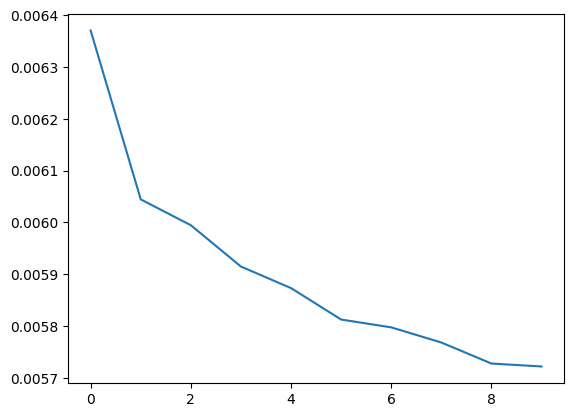

In [ ]:
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [41]:
model.save("modelo_prediccion_imagenes.keras")

In [22]:
model = load_model("modelo_prediccion_imagenes.keras")

In [38]:
def predict_next_image(model, session, inicio, fin, n_timesteps):

    paths = session[inicio:fin+1]         # imagenes de indice inicio a fin
    if len(paths) < n_timesteps:
        print("Warning: la ventana es menor que n_timesteps")
        return None

    # Asegurar que la ventana tiene exactamente n_timesteps
    last_n = paths[-n_timesteps:]
    last_n_imgs = [load_and_preprocess(p) for p in last_n]
    X = np.array([np.array(last_n_imgs)])  # (1, n_timesteps, 256, 256, 3)

    pred = model.predict(X)                # (1, 256, 256, 3)
    return pred[0]

In [1]:
session_name = sessions_test[0]                   

session_paths = seq_by_session[session_name]      

y_pred = predict_next_image(model, session_paths, 0, 100, window_size)

NameError: name 'sessions_test' is not defined

Forma de y_pred: (256, 256, 3)


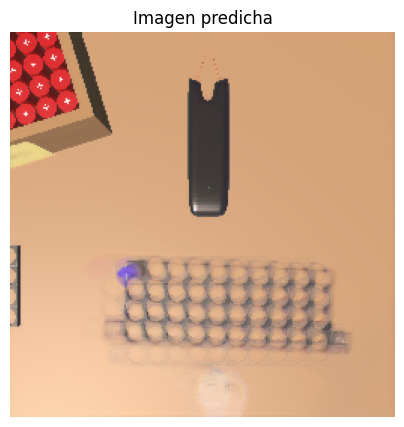

In [43]:
print("Forma de y_pred:", y_pred.shape)  # comprueba que es (256, 256, 3)

plt.figure(figsize=(5, 5))
plt.imshow(y_pred)
plt.title("Imagen predicha")
plt.axis("off")
plt.show()

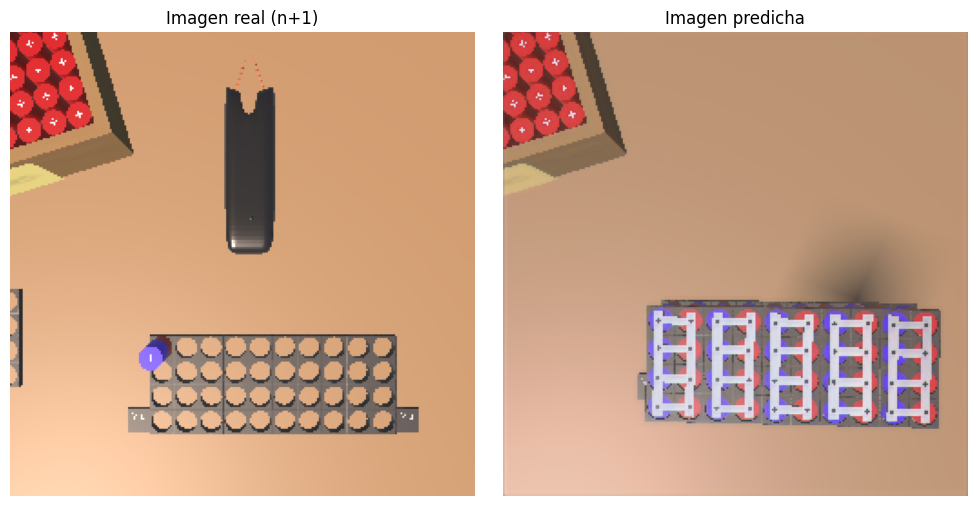

In [ ]:
# Elegir un índice cualquiera
idx = 0

# Imagen real (la que el modelo debería predecir)
img_real = Y_total[idx]  # (256, 256, 3)

# Imagen predicha
img_pred = y_pred   # (256, 256, 3)

# Mostrar original y predicción lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(img_real)
ax1.set_title("Imagen real (n+1)")
ax1.axis("off")

ax2.imshow(img_pred)
ax2.set_title("Imagen predicha")
ax2.axis("off")

plt.tight_layout()
plt.show()

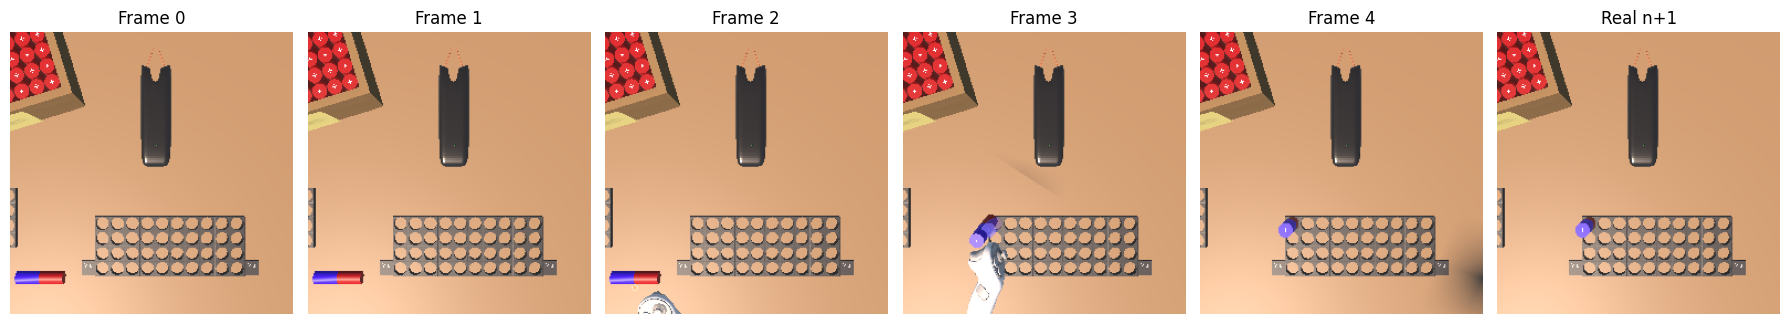

In [ ]:
# 5 imágenes de entrada para la muestra idx
input_seq = X_total[idx]  # (5, 256, 256, 3)

fig, axes = plt.subplots(1, 6, figsize=(18, 4))

# Mostrar los 5 frames de entrada
for i in range(5):
    axes[i].imshow(input_seq[i])
    axes[i].set_title(f"Frame {i}")
    axes[i].axis("off")

# Mostrar la real y la predicha
axes[5].imshow(img_real)
axes[5].set_title("Real n+1")
axes[5].axis("off")

plt.tight_layout()
plt.show()